In [18]:
! pip install sox
! pip install librosa
! pip install audiomentations==0.23.0
! pip install pydub

In [56]:
import os
import sox
import librosa
import pandas as pd
import soundfile as sf
#import subprocess

from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift
import numpy as np

In [5]:
df = pd.read_csv("../lists/GPS_cmd_pyin_setup_1_test.csv")
df.head()

,filepaths,users,genders,words,f0
0,/home/jovyan/work/OneDrive/Documentos/Doutorad...,F017,F,academia,258
1,/home/jovyan/work/OneDrive/Documentos/Doutorad...,F017,F,academia,258
2,/home/jovyan/work/OneDrive/Documentos/Doutorad...,F017,F,academia,258
3,/home/jovyan/work/OneDrive/Documentos/Doutorad...,F017,F,academia,258
4,/home/jovyan/work/OneDrive/Documentos/Doutorad...,F017,F,academia,258


In [6]:
x = df['filepaths'][0]
x

'/home/jovyan/work/OneDrive/Documentos/Doutorado/dataset/GPS_cmd_16k_renamed/academia_F017_001.wav'

In [7]:
audio = librosa.load("../academia_F017_001.wav", sr=16000)[0]
audio

array([ 0.0012207 ,  0.0022583 ,  0.00213623, ..., -0.0039978 ,
       -0.00415039, -0.00457764], dtype=float32)

In [ ]:
# # Example: Mixes the input with background noise scaled to a volume of 0.05
# sox -m input.wav <(sox background.wav -v 0.05) final_output.wav

# Example: Adds synthesized brown noise at 2% volume to your input
# sox input.wav output_with_noise.wav synth whitenoise vol 0.02


In [10]:
input = "academia_F017_001.wav"
output = "academia_F017_001_mixed_white.wav"

In [11]:
# whitenoise with pinknoise or brownnoise
# result = subprocess.run([f"sox {input} {output} synth whitenoise vol 0.02"], capture_output=True, text=True)
# result

FileNotFoundError: [Errno 2] No such file or directory: 'sox academia_F017_001.wav academia_F017_001_mixed_white.wav synth whitenoise vol 0.02'

In [ ]:
# tfm = sox.Transformer()
# tfm.reverb(reverberance=100, high_freq_damping=50, room_scale=100, stereo_depth=100, pre_delay=0,
# wet_gain=0, wet_only=True)
# tfm.build('teste_imp6.wav', 'test_reverberation/imp6_sd100.wav')

In [ ]:
# augment = Compose([
#     AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
#     TimeStretch(min_rate=0.8, max_rate=1.25, p=0.5),
#     PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
#     Shift(min_fraction=-0.5, max_fraction=0.5, p=0.5),
# ])
# # Generate 2 seconds of dummy audio for the sake of example
# samples = np.random.uniform(low=-0.2, high=0.2, size=(32000,)).astype(np.float32)
# # Augment/transform/perturb the audio data
# augmented_samples = augment(samples=samples, sample_rate=16000)

In [14]:
#help(sox)
help(sox.Transformer())

Help on Transformer in module sox.transform object:

class Transformer(builtins.object)
 |  Audio file transformer.
 |  Class which allows multiple effects to be chained to create an output
 |  file, saved to output_filepath.
 |  
 |  
 |  
 |  Methods
 |  -------
 |  set_globals
 |      Overwrite the default global arguments.
 |  build
 |      Execute the current chain of commands to create an output file.
 |  build_file
 |      Alias of build.
 |  build_array
 |      Execute the current chain of commands to create an output array.
 |  
 |  Methods defined here:
 |  
 |  __init__(self)
 |      Attributes
 |      ----------
 |      input_format : list of str
 |          Input file format arguments that will be passed to SoX.
 |      output_format : list of str
 |          Output file format arguments that will be bassed to SoX.
 |      effects : list of str
 |          Effects arguments that will be passed to SoX.
 |      effects_log : list of str
 |          Ordered sequence of effect

In [ ]:
tfm = sox.Transformer()
tfm.reverb(reverberance=100, high_freq_damping=50, room_scale=100, stereo_depth=100, pre_delay=0,
wet_gain=0, wet_only=True)
tfm.build('teste_imp6.wav', 'test_reverberation/imp6_sd100.wav')

In [19]:
from pydub import AudioSegment

In [ ]:
def add_background_noise(voice_path, noise_path, output_path, noise_gain_db=-15):
    # Load primary speech and background noise files
    voice = AudioSegment.from_file(voice_path)
    noise = AudioSegment.from_file(noise_path)
    
    # Lower the background noise volume so it does not drown out the speech
    noise = noise + noise_gain_db    
    # Loop the noise file if it is shorter than the speech file
    if len(noise) < len(voice):
        noise = noise * (len(voice) // len(noise) + 1)        
    # Crop the noise to exactly match the speech length
    noise = noise[:len(voice)]    
    # Overlay the tracks together
    mixed_audio = voice.overlay(noise)    
    # Save the output file
    mixed_audio.export(output_path, format="wav")

# Example Usage
add_background_noise("speech.wav", "rain_ambience.wav", "noisy_speech.wav", noise_gain_db=-20)

In [ ]:

white_noise = np.random.normal(loc=0, scale=1, size=1000)

In [28]:
# def organize_paths(filepath, gain):
#     out_folder = os.path.dirname(filepath).replace("GPS_cmd_16k_renamed", "GPS_cmd_16k_renamed_mix_white")
#     os.makedirs(out_folder, exist_ok=True)
#     out_path = os.path.basename(filepath).replace(".wav", f"_{gain}dB_white_noise.wav")
#     out = f"{out_folder}/{out_path}"
#     return out

def apply_white_noise(speech_path, output_path, target_snr_db):
    sr = 16000
    speech = librosa.load(speech_path, sr=sr)[0]
    #speech = AudioSegment.from_file(speech_path)
    white_noise = np.random.normal(loc=0, scale=1, size=len(speech))
    # noise = white_noise + noise_gain_db
    # mixed_audio = speech.overlay(noise)
    # mixed_audio.export(output_path, format="wav")

    power_speech = np.mean(speech ** 2)
    power_noise = np.mean(white_noise ** 2)
    
    if power_noise == 0:
        return speech
        
    # Formula derived from: SNR_dB = 10 * log10(Power_clean / Power_noise_scaled)
    target_snr_linear = 10 ** (target_snr_db / 10.0)
    scaling_factor = np.sqrt(power_speech / (power_noise * target_snr_linear))
    speech_mixed = speech + (scaling_factor * white_noise)
    speech_mixed_norm = librosa.util.normalize(speech_mixed)

    sf.write(output_path, speech_mixed_norm, sr)
    

In [29]:
mixed_filepaths = []
for filepath in df['filepaths'][0:2]:
    gains = [5, 10, 20]
    gain = np.random.choice(gains)
    output_filepath = organize_paths(filepath, gain)
    print(gain)
    apply_white_noise(filepath, output_filepath, gain)
    

20
-5


In [41]:
def organize_paths(filepath, value, effect_name, suffix=""):
    out_folder = os.path.dirname(filepath).replace("GPS_cmd_16k_renamed", f"GPS_cmd_16k_renamed_mix_{effect_name}")
    os.makedirs(out_folder, exist_ok=True)
    out_path = os.path.basename(filepath).replace(".wav", f"_{value}{suffix}_{effect_name}.wav")
    out = f"{out_folder}/{out_path}"
    return out

In [58]:
def apply_reverb(speech_path, output_path, tfm, value):
    tfm = sox.Transformer()
    tfm.reverb(reverberance=value, high_freq_damping=50, room_scale=100, stereo_depth=100, pre_delay=0, wet_gain=0, wet_only=True)
    #tfm.build('teste_imp6.wav', 'test_reverberation/imp6_sd100.wav')
    tfm.build(speech_path, output_path)

In [ ]:
import numpy as np
from scipy.io import wavfile

def apply_echo(file_path, output_path, delay_seconds=0.3, attenuation=0.5):
    # Load the original WAV file
    sample_rate, data = wavfile.read(file_path)
    
    # Ensure data is handled as float to avoid integer clipping during mixing
    original_signal = data.astype(np.float32)
    
    # Calculate how many samples correspond to the delay time
    delay_samples = int(delay_seconds * sample_rate)
    
    # Create an empty array large enough to hold the original audio plus its trailing echo
    output_signal = np.zeros(len(original_signal) + delay_samples, dtype=np.float32)
    
    # Add the original signal at the start
    output_signal[:len(original_signal)] += original_signal
    
    # Add the delayed, quieter version of the signal
    output_signal[delay_samples:delay_samples + len(original_signal)] += original_signal * attenuation
    
    # Normalize the audio back to 16-bit boundaries to prevent distortion
    output_signal = np.clip(output_signal, -32768, 32767).astype(np.int16)
    
    # Save the new file
    wavfile.write(output_path, sample_rate, output_signal)

# Example usage
apply_echo("input.wav", "output_echo.wav", delay_seconds=0.4, attenuation=0.6)


In [59]:
effect_name = "reverb"
tfm = sox.Transformer()

mixed_filepaths = []
for filepath in df['filepaths'][0:2]:
    values = [10, 30, 60]
    value = np.random.choice(gains)
    output_filepath = organize_paths(filepath, value, effect_name)
    print(output_filepath)
    apply_reverb(filepath, output_filepath, tfm, value)

This install of SoX cannot process .wav files.
This install of SoX cannot process .wav files.


/home/jovyan/work/OneDrive/Documentos/Doutorado/dataset/GPS_cmd_16k_renamed_mix_reverb/academia_F017_001_5_reverb.wav


FileNotFoundError: [Errno 2] No such file or directory: 'sox'

In [33]:
import IPython.display as ipd
import matplotlib.pyplot as plt

In [50]:
import glob
#data = glob.glob("/home/jovyan/work/OneDrive/Documentos/Doutorado/dataset/GPS_cmd_16k_renamed_mix_white/*.wav")
data = glob.glob("/home/jovyan/work/OneDrive/Documentos/Doutorado/dataset/GPS_cmd_16k_renamed_mix_reverb/*.wav")

In [51]:
data

['/home/jovyan/work/OneDrive/Documentos/Doutorado/dataset/GPS_cmd_16k_renamed_mix_reverb/academia_F017_001_5_reverb.wav',
 '/home/jovyan/work/OneDrive/Documentos/Doutorado/dataset/GPS_cmd_16k_renamed_mix_reverb/academia_F017_002_5_reverb.wav']

In [52]:
audio = librosa.load(data[1], sr=16000)[0]

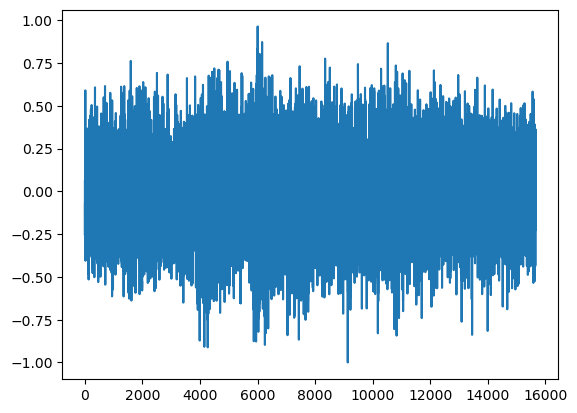

In [53]:
ipd.display(ipd.Audio(audio, rate=16000, normalize=False))
plt.plot(audio)

## References:
- https://pypi.org/project/audiomentations/0.23.0/